In [20]:
#installation and set up
!pip install -U spacy
!python -m spacy download en
!ppip install -U scikit-learn numpy pandas
!pip install datasets
!pip install transformers datasets accelerate -q

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/spacy/__main__.py", line 4, in <module>
    setup_cli()
  File "/opt/anaconda3/lib/python3.12/site-packages/spacy/cli/_util.py", line 77, in setup_cli
    command = get_command(app)
              ^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/typer/main.py", line 350, in get_command
    click_command: click.Command = get_group(typer_instance)
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/typer/main.py", line 332, in get_group
    group = get_group_from_info(
            ^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/typer/main.py", line 483, in get_group_from_info
    command = get_command_from_info(
              ^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packa

In [21]:
import matplotlib.pyplot as plt
import re
import pandas as pd
import seaborn as sns
sns.set_theme(style="whitegrid")

import numpy as np
import pandas as pd
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)

1. DATA EXPLORATORY ANALYSIS AND DATA CLEANING

In [22]:
#Imports and Load Data
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
train_df.head()

Training set shape: (3200, 2)
Test set shape: (800, 1)


,content,category
0,The senator announced new taxation policy today.,politics
1,Market shows improvement following economic in...,business
2,The senator announced new education policy today.,politics
3,CEO announces strategic changes in logistics o...,business
4,New film release breaks box office records.,entertainment


In [23]:
# Check missing values
print("\n--- Missing Values Check ---")
print("Train missing values:\n", train_df.isnull().sum())
print("Test missing values:\n", test_df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows in Train: {train_df.duplicated().sum()}")
print(f"Duplicate rows in Test: {test_df.duplicated().sum()}")


--- Missing Values Check ---
Train missing values:
 content     0
category    0
dtype: int64
Test missing values:
 content    0
dtype: int64

Duplicate rows in Train: 3048
Duplicate rows in Test: 665


Machine learning models usually require complete data.

In [24]:
train_df['category'].unique()
train_df['category'].value_counts()

category
politics         654
technology       652
sports           639
entertainment    631
business         624
Name: count, dtype: int64

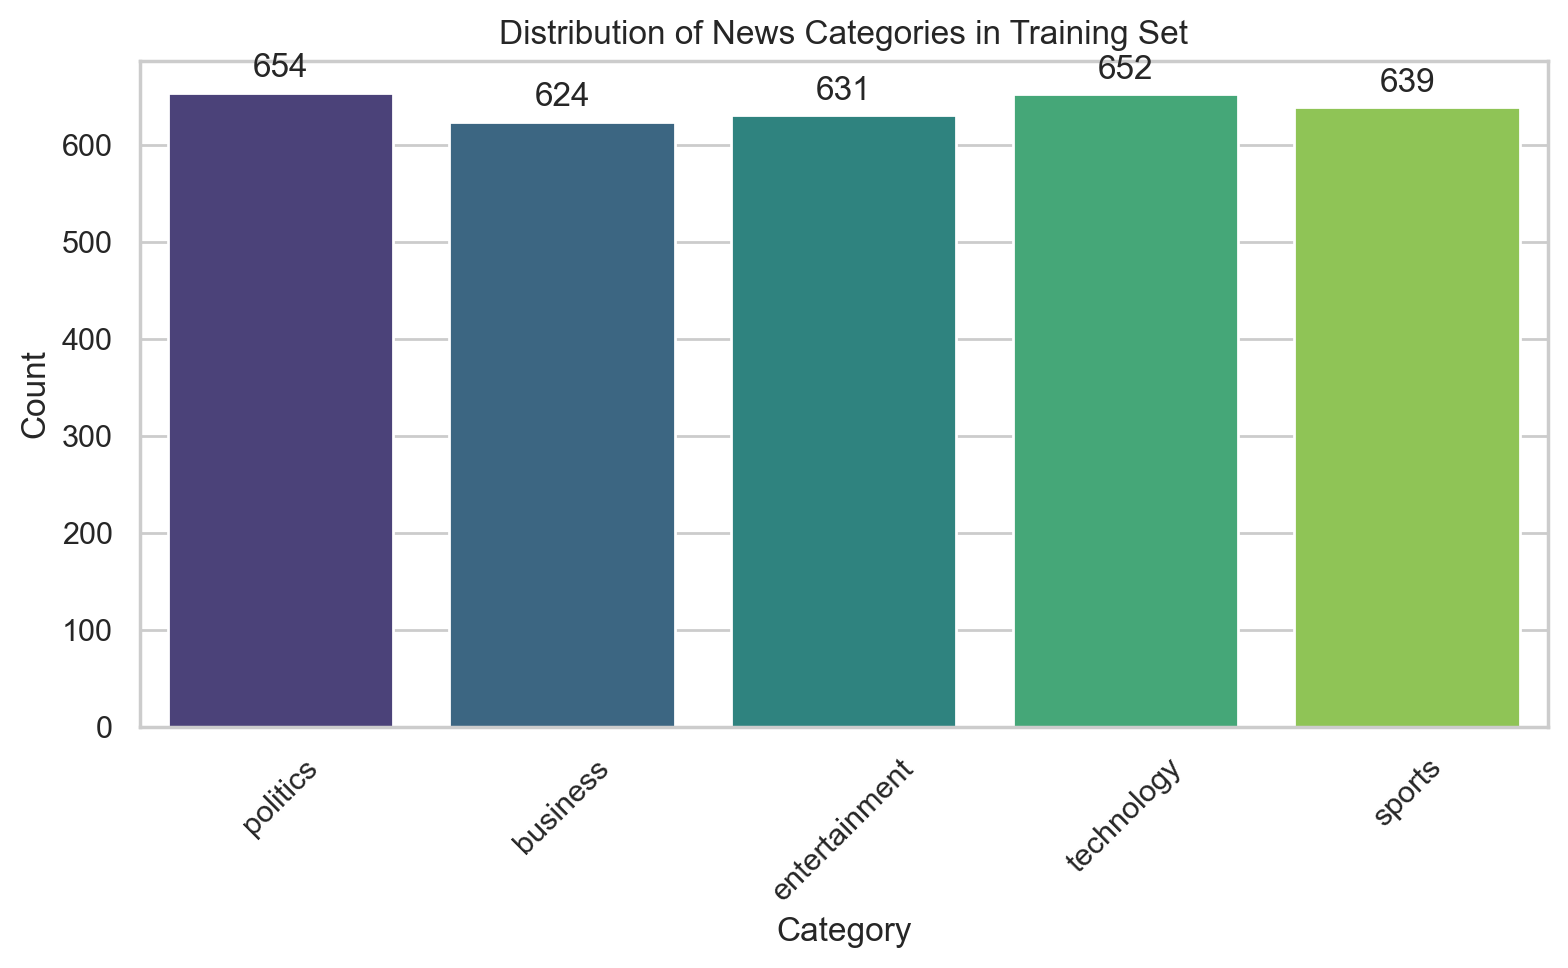

In [25]:
# Class Distribution Plot
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=train_df,
    x="category",
    hue="category",  # Assign hue to the same variable
    palette="viridis",
    legend=False,  # Hide the redundant legend
)
plt.title("Distribution of News Categories in Training Set")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
    )
plt.tight_layout()
plt.show()

In [26]:
print(f"Original training set shape: {train_df.shape}")
print("\nCategory distribution in full training set:")
print(train_df["category"].value_counts(normalize=True) * 100)

Original training set shape: (3200, 2)

Category distribution in full training set:
category
politics         20.43750
technology       20.37500
sports           19.96875
entertainment    19.71875
business         19.50000
Name: proportion, dtype: float64


In [27]:
def clean_text(text):
    if pd.isna(text):
        return ""
    # Convert to string and lowercase
    text = str(text).lower()
    # Remove HTML tags if present
    text = re.sub(r"<.*?>", "", text)
    # Remove punctuation/special characters except standard alphanumeric and spaces
    text = re.sub(r"[^\w\s]", "", text)
    # Remove extra whitespaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [28]:
# Apply cleaning to content
train_df["cleaned_content"] = train_df["content"].apply(clean_text)

# Drop rows where content became empty after cleaning
train_df = train_df[train_df["cleaned_content"] != ""]
print(f"Cleaned dataset shape: {train_df.shape}")

Cleaned dataset shape: (3200, 3)


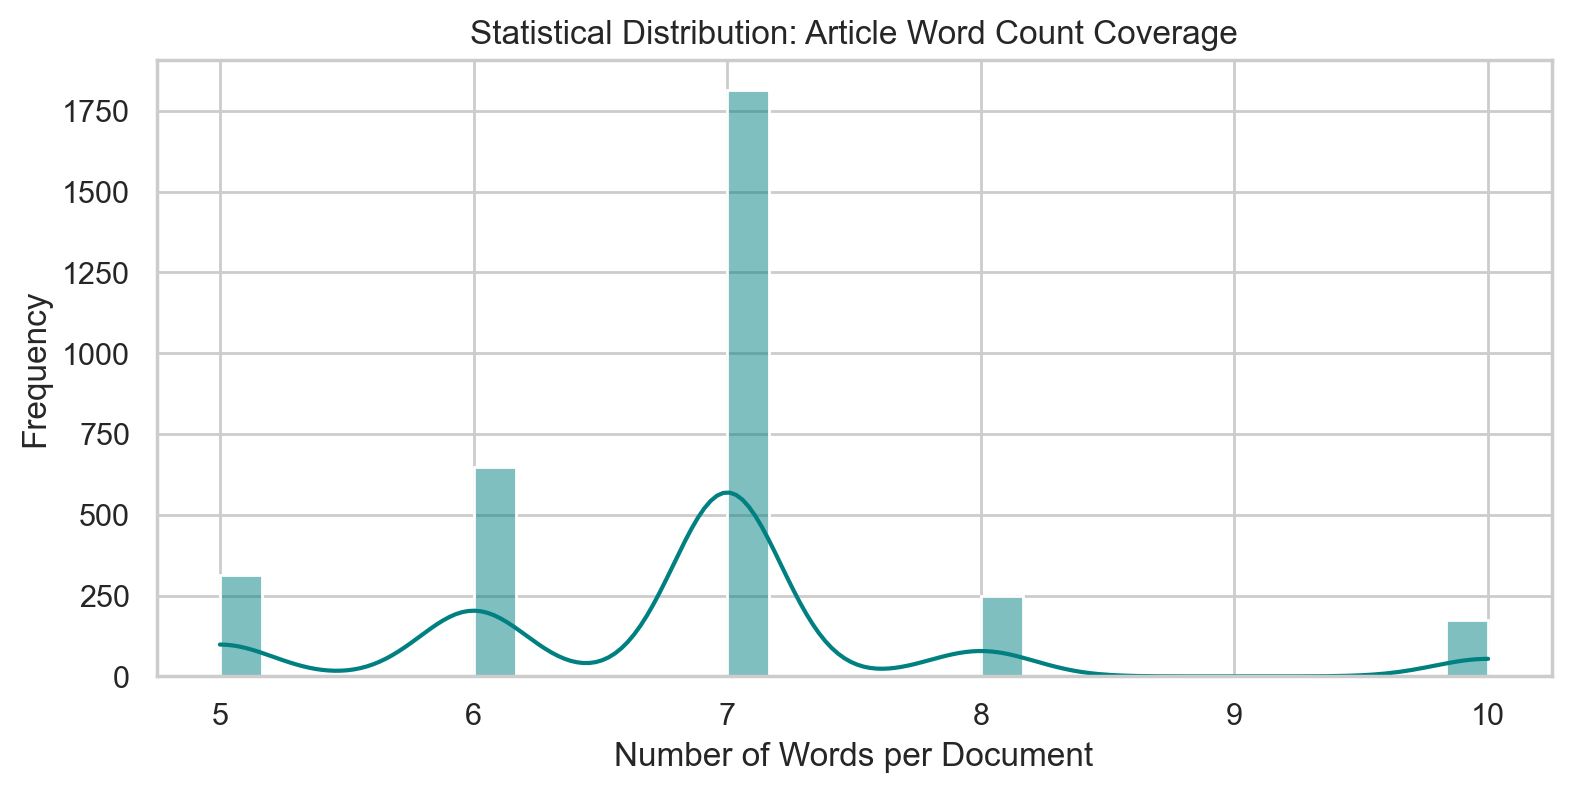

In [29]:
#Coverage / Vocabulary Length Distribution (Word Count per Article)
train_df["word_count"] = train_df["cleaned_content"].apply(
    lambda x: len(x.split())
)

plt.figure(figsize=(9, 4))
sns.histplot(train_df["word_count"], bins=30, kde=True, color="teal")
plt.title("Statistical Distribution: Article Word Count Coverage")
plt.xlabel("Number of Words per Document")
plt.ylabel("Frequency")
plt.show()

In [30]:
print(train_df['cleaned_content'][0])

the senator announced new taxation policy today


In [31]:
#Perform Stratified Train/Validation Split
# test_size=0.2 means 80% for training and 20% for validation
train_data, val_data = train_test_split(
    train_df, test_size=0.2, random_state=42, stratify=train_df["category"]
)

print(f"\nNew Train split shape: {train_data.shape}")
print(f"New Validation split shape: {val_data.shape}")


New Train split shape: (2560, 4)
New Validation split shape: (640, 4)


In [32]:
# 4. Verify class proportions in both splits
print("\nTrain split category distribution (%):")
print(train_data["category"].value_counts(normalize=True) * 100)

print("\nValidation split category distribution (%):")
print(val_data["category"].value_counts(normalize=True) * 100)


Train split category distribution (%):
category
politics         20.429688
technology       20.390625
sports           19.960938
entertainment    19.726562
business         19.492188
Name: proportion, dtype: float64

Validation split category distribution (%):
category
politics         20.46875
technology       20.31250
sports           20.00000
entertainment    19.68750
business         19.53125
Name: proportion, dtype: float64


Using spaCy (as referenced in your NLP Introduction course material), you can extract part-of-speech (POS) tags, lemmas, and syntactic dependencies.

#3. Transformer-based Approach

In [33]:
# 1. Assume train_data and val_data are already split from your EDA step
# Example: train_data, val_data = train_test_split(...)

# Map string labels to integers
labels = sorted(train_data["category"].unique())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}

train_data["label"] = train_data["category"].map(label2id)
val_data["label"] = val_data["category"].map(label2id)

# Convert pandas DataFrames to Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(train_data[["content", "label"]])
val_dataset = Dataset.from_pandas(val_data[["content", "label"]])

In [34]:
# 2. Load tokenizer and model
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)


def tokenize_function(examples):
  return tokenizer(
      examples["content"], padding="max_length", truncation=True, max_length=128
  )


tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

# Initialize model for 5 news categories
model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6923.35it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In the warnings: Hugging Face allows us to download public models like distilbert-base-uncased without an account token. However, if you make too many requests, you might hit a rate limit. You can safely ignore this for standard project usage unless you are downloading hundreds of large models rapidly.
The Load Report Table (UNEXPECTED vs MISSING)When you loaded AutoModelForSequenceClassification using distilbert-base-uncased, the model weights were pulled from the Hugging Face hub. Because you are adapting a general language model for a classification task, two things happened:UNEXPECTED Keys (Top of the list):These refer to the original pre-trained weights for the Masked Language Modeling (MLM) head (e.g., vocab_transform, vocab_projector).Why it says this: Since DistilBERT was originally pre-trained to predict masked words in sentences (MLM), those specific output layers aren't needed for your news category classification task. Hugging Face drops them automatically, which is completely expected.  MISSING Keys (Bottom of the list):These refer to the new classification head layers (classifier.weight, classifier.bias, etc.) that map the transformer outputs to your specific number of classes (your 5 news categories).Why it says this: Because these classification layers are brand new for your custom categories, they start with randomly initialized weights. The Trainer will learn optimal weights for them during your fine-tuning process.

In [35]:
# 3. Define metrics computation
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = np.argmax(logits, axis=1)
  precision, recall, f1, _ = precision_recall_fscore_support(
      labels, preds, average="weighted"
  )
  acc = accuracy_score(labels, preds)
  return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}


# 4. Training configuration
training_args = TrainingArguments(
    output_dir="./distilbert_news_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

# 5. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

# Run fine-tuning
trainer.train()

  0%|          | 0/480 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
                                                 
 33%|███▎      | 160/480 [05:21<08:18,  1.56s/it]

{'eval_loss': '0.01406', 'eval_accuracy': '1', 'eval_f1': '1', 'eval_precision': '1', 'eval_recall': '1', 'eval_runtime': '18.62', 'eval_samples_per_second': '34.37', 'eval_steps_per_second': '2.148', 'epoch': '1'}


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.85s/it]
/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
                                                 
 67%|██████▋   | 320/480 [11:48<05:39,  2.12s/it]

{'eval_loss': '0.006127', 'eval_accuracy': '1', 'eval_f1': '1', 'eval_precision': '1', 'eval_recall': '1', 'eval_runtime': '16.94', 'eval_samples_per_second': '37.79', 'eval_steps_per_second': '2.362', 'epoch': '2'}


Writing model shards: 100%|██████████| 1/1 [00:04<00:00,  4.57s/it]
/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
                                                 
100%|██████████| 480/480 [21:28<00:00,  1.26s/it]

{'eval_loss': '0.004867', 'eval_accuracy': '1', 'eval_f1': '1', 'eval_precision': '1', 'eval_recall': '1', 'eval_runtime': '15.33', 'eval_samples_per_second': '41.74', 'eval_steps_per_second': '2.609', 'epoch': '3'}


100%|██████████| 480/480 [21:32<00:00,  1.26s/it]

{'train_runtime': '1293', 'train_samples_per_second': '5.94', 'train_steps_per_second': '0.371', 'train_loss': '0.1166', 'epoch': '3'}


100%|██████████| 480/480 [21:34<00:00,  2.70s/it]


TrainOutput(global_step=480, training_loss=0.11660741964975993, metrics={'train_runtime': 1292.9889, 'train_samples_per_second': 5.94, 'train_steps_per_second': 0.371, 'total_flos': 254351012659200.0, 'train_loss': 0.11660741964975993, 'epoch': 3.0})

In [36]:
eval_metrics = trainer.evaluate()
print("Validation Metrics:")
for key, value in eval_metrics.items():
  print(f"{key}: {value:.4f}")

/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 40/40 [00:13<00:00,  2.87it/s]


Validation Metrics:
eval_loss: 0.0141
eval_accuracy: 1.0000
eval_f1: 1.0000
eval_precision: 1.0000
eval_recall: 1.0000
eval_runtime: 17.8777
eval_samples_per_second: 35.7990
eval_steps_per_second: 2.2370
epoch: 3.0000


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 40/40 [00:12<00:00,  3.14it/s]


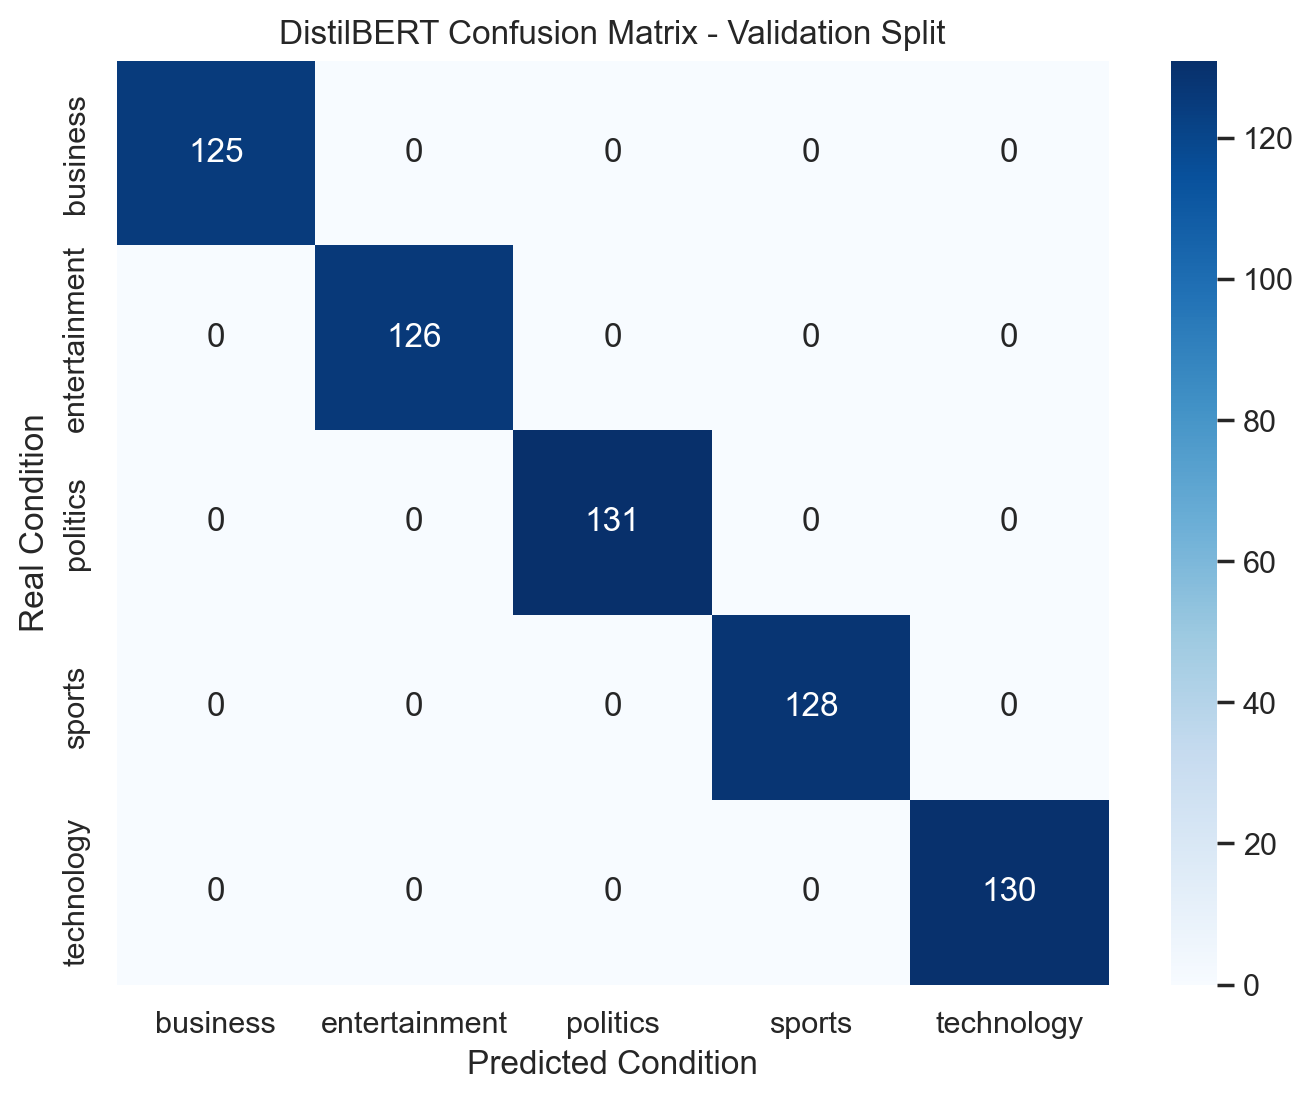


Detailed Classification Report:
               precision    recall  f1-score   support

     business       1.00      1.00      1.00       125
entertainment       1.00      1.00      1.00       126
     politics       1.00      1.00      1.00       131
       sports       1.00      1.00      1.00       128
   technology       1.00      1.00      1.00       130

     accuracy                           1.00       640
    macro avg       1.00      1.00      1.00       640
 weighted avg       1.00      1.00      1.00       640



In [37]:
from sklearn.metrics import confusion_matrix, classification_report
# 1. Get predictions from the trainer on your tokenized validation set
predictions_output = trainer.predict(tokenized_val)
preds = np.argmax(predictions_output.predictions, axis=1)
true_labels = predictions_output.label_ids

# 2. Generate Confusion Matrix
cm = confusion_matrix(true_labels, preds)
categories = sorted(val_data['category'].unique())

# 3. Plotting using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=categories, yticklabels=categories)
plt.title('DistilBERT Confusion Matrix - Validation Split')
plt.xlabel('Predicted Condition')
plt.ylabel('Real Condition')
plt.show()

# 4. Print detailed classification report (Precision, Recall, F1 per class)
print("\nDetailed Classification Report:")
print(classification_report(true_labels, preds, target_names=categories))

DistilBERT is created using model distillation where a smaller student model (6 encoder layers) learns to mimic a larger teacher model (BERT-base, 12 encoder layers). Because it has roughly 40% fewer parameters, it trains significantly faster and requires less memory